# Modellazione Predittiva del Risk Score: Regressione Lineare e XGBRegressor a Confronto

## Obiettivo
L'obiettivo di questo progetto è sviluppare un sistema di Machine Learning in grado di prevedere in modo accurato il RiskScore di un cliente, utilizzando e mettendo a confronto due modelli predittivi specifici: la **Linear Regression** e **XGBRegressor**.

## Importazione Librerie e Caricamento Dati

In [14]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
# Download latest version
path = kagglehub.dataset_download("lorenzozoppelletto/financial-risk-for-loan-approval")

# Trova il file CSV all'interno della cartella scaricata
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0] # Prende il primo file CSV trovato
full_file_path = os.path.join(path, csv_file)

# Carica il dataset in un DataFrame
df = pd.read_csv(full_file_path)

## Exploratory Data Analysis

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

Il dataset include diverse feature come informazioni demografiche, storico creditizio, situazione lavorativa, livelli di reddito, debito esistente e altre metriche finanziarie rilevanti, fornendo una base completa per un'analisi sofisticata e un processo decisionale guidato dai dati.

* **ApplicationDate:** Data di richiesta del prestito
* **Age:** Età del richiedente
* **AnnualIncome:** Reddito annuale
* **CreditScore:** Punteggio di affidabilità creditizia (Credit Score)
* **EmploymentStatus:** Situazione lavorativa
* **EducationLevel:** Livello di istruzione massimo raggiunto
* **Experience:** Anni di esperienza lavorativa
* **LoanAmount:** Importo del prestito richiesto
* **LoanDuration:** Durata del prestito (periodo di rimborso)
* **MaritalStatus:** Stato civile del richiedente
* **NumberOfDependents:** Numero di persone a carico
* **HomeOwnershipStatus:** Tipologia di possesso dell'abitazione
* **MonthlyDebtPayments:** Rata mensile dei debiti esistenti
* **CreditCardUtilizationRate:** Percentuale di utilizzo delle carte di credito
* **NumberOfOpenCreditLines:** Linee di credito attualmente attive
* **NumberOfCreditInquiries:** Numero di controlli recenti sul credito
* **DebtToIncomeRatio:** Rapporto debito/reddito
* **BankruptcyHistory:** Storico di bancarotta
* **LoanPurpose:** Motivo della richiesta del prestito
* **PreviousLoanDefaults:** Precedenti inadempienze sui prestiti (Default)
* **PaymentHistory:** Comportamento dei pagamenti passati
* **LengthOfCreditHistory:** Durata dello storico creditizio
* **SavingsAccountBalance:** Saldo del conto di risparmio
* **CheckingAccountBalance:** Saldo del conto corrente
* **TotalAssets:** Totale delle attività/beni posseduti
* **TotalLiabilities:** Totale delle passività/debiti
* **MonthlyIncome:** Reddito mensile
* **UtilityBillsPaymentHistory:** Storico dei pagamenti delle utenze domestiche
* **JobTenure:** Anni di anzianità nell'impiego attuale
* **NetWorth:** Valore del patrimonio netto totale
* **BaseInterestRate:** Tasso di interesse di base
* **InterestRate:** Tasso di interesse applicato
* **MonthlyLoanPayment:** Rata mensile del prestito stimata/calcolata
* **TotalDebtToIncomeRatio:** Rapporto tra debito totale e reddito
* **LoanApproved:** Stato di approvazione del prestito (Approvato/Rifiutato)
* **RiskScore:** Punteggio di valutazione del rischio *(Variabile Target da prevedere)*

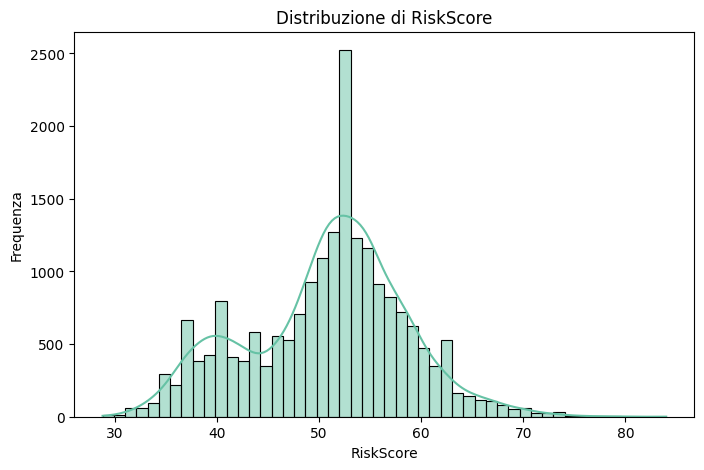

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(df['RiskScore'], bins=50, kde=True, color='#66C2A5FF')
plt.title('Distribuzione di RiskScore')
plt.xlabel('RiskScore')
plt.ylabel('Frequenza')
plt.show()

L'analisi visiva della variabile target rivela alcune dinamiche fondamentali sui dati che andremo a modellare:

* **Distribuzione Bimodale:** La curva non presenta una singola forma a campana standard, ma mostra due raggruppamenti (o "gobbe") distinti. Esiste un picco minore intorno al valore **40** e uno principale molto più pronunciato. Questo suggerisce la presenza di due "popolazioni" o tipologie di clienti ben distinte all'interno del dataset.
* **Picco Anomalo (Spike):** Il picco principale, situato tra i punteggi **52 e 53**, è estremamente elevato (supera la frequenza di 2500). Una concentrazione così anomala su un singolo valore spesso indica una regola di business preesistente: potrebbe trattarsi di un punteggio standard o di default assegnato automaticamente a una specifica categoria di richiedenti (ad esempio, chi non possiede uno storico creditizio sufficiente).
* **Asimmetria Positiva (Coda verso destra):** La distribuzione si allunga progressivamente verso i valori più alti, esaurendosi gradualmente dopo quota 80. Ci sono quindi relativamente poche richieste con un RiskScore estremamente elevato.

Questa specifica morfologia dei dati fornisce importanti indizi sul potenziale comportamento dei nostri algoritmi:
1. **Linear Regression:** Potrebbe incontrare delle difficoltà. I modelli lineari offrono le migliori performance quando la variabile target ha una distribuzione normale. Tracciare un piano lineare che ottimizzi l'errore per entrambe le popolazioni distinte risulterà matematicamente complesso e potrebbe generare un errore medio (MAE) più alto.
2. **XGBRegressor:** Si adatterà perfettamente a questo scenario. Gli algoritmi basati su alberi decisionali gestiscono in modo eccellente le distribuzioni bimodali e asimmetriche, poiché possono creare agilmente delle "regole di taglio" (if/else) per isolare il gruppo del picco a 40 da quello del picco a 52.

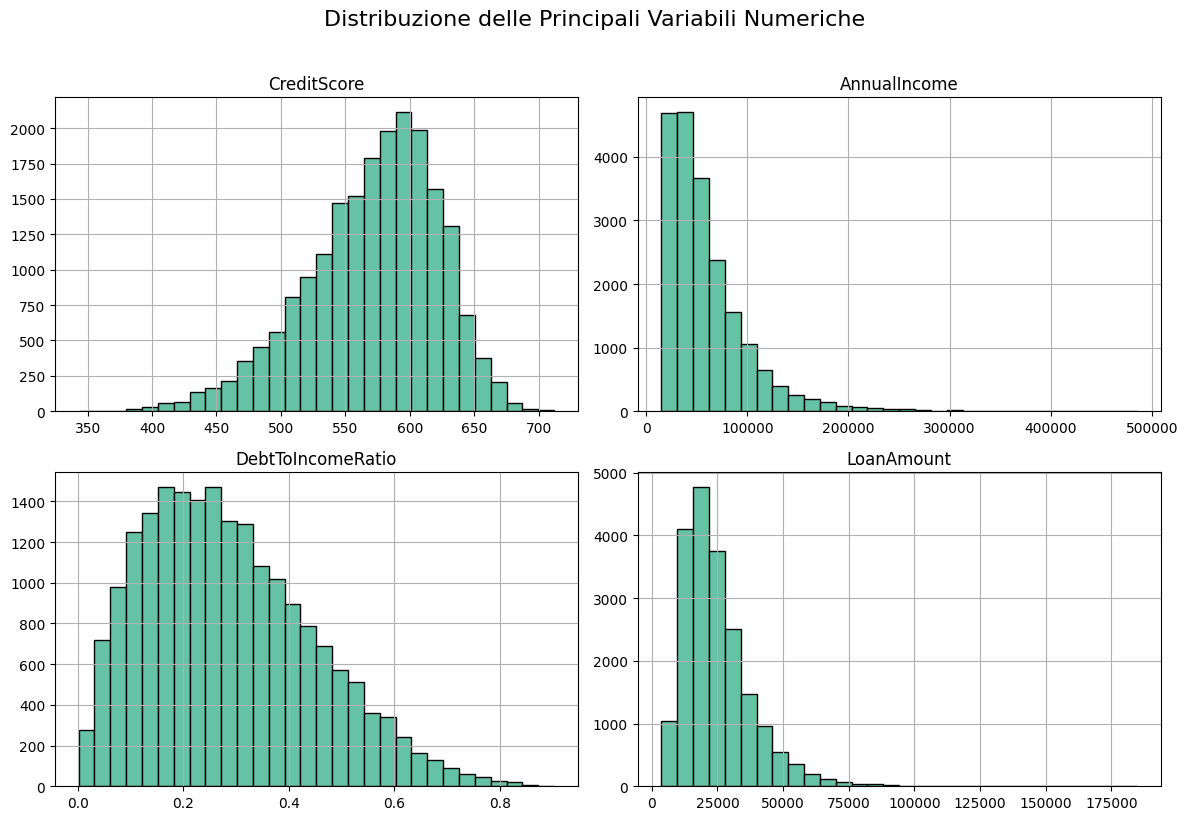

In [ ]:
features_num = ['CreditScore', 'AnnualIncome', 'DebtToIncomeRatio', 'LoanAmount']

df[features_num].hist(bins=30, figsize=(12, 8), color='#66C2A5FF', edgecolor='black')

plt.suptitle('Distribuzione delle Principali Variabili Numeriche', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

* **CreditScore:** Presenta un'asimmetria negativa (coda allungata verso sinistra). La maggior parte dei richiedenti si concentra nella fascia medio-alta, con un picco tra 550 e 650 punti.
* **AnnualIncome e LoanAmount:** Entrambe le variabili mostrano una forte asimmetria positiva (coda molto lunga verso destra). La maggior parte dei clienti ha redditi e richiede prestiti di importo medio-basso.
* **DebtToIncomeRatio:** Ha una distribuzione più morbida ma sempre tendente a destra, con la massa principale dei clienti che impegna tra il 10% e il 40% del proprio reddito per ripagare debiti.

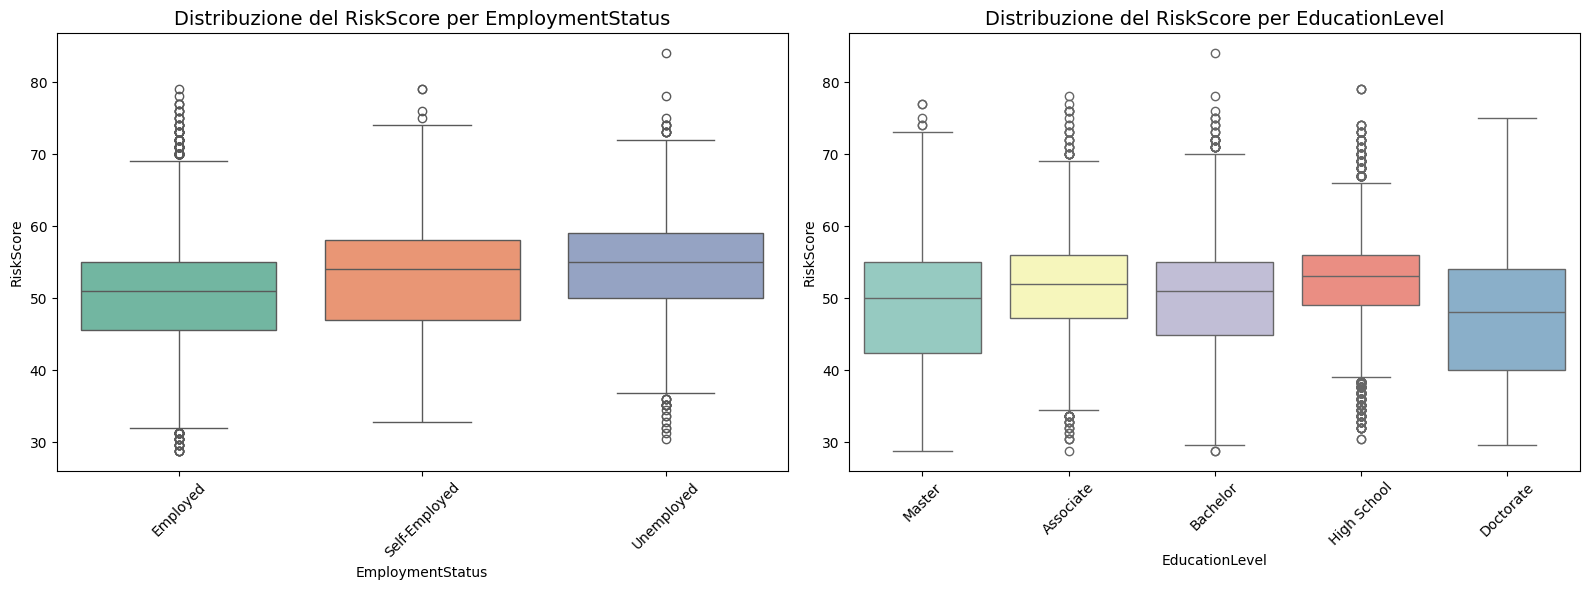

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot per lo stato occupazionale
sns.boxplot(ax=axes[0], data=df, x='EmploymentStatus', y='RiskScore', hue='EmploymentStatus', palette='Set2', legend=False)
axes[0].set_title('Distribuzione del RiskScore per EmploymentStatus', fontsize=14)
axes[0].set_xlabel('EmploymentStatus')
axes[0].set_ylabel('RiskScore')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot per il livello di istruzione
sns.boxplot(ax=axes[1], data=df, x='EducationLevel', y='RiskScore', hue='EducationLevel', palette='Set3', legend=False)
axes[1].set_title('Distribuzione del RiskScore per EducationLevel', fontsize=14)
axes[1].set_xlabel('EducationLevel')
axes[1].set_ylabel('RiskScore')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Impatto di EmploymentStatus:** Si nota una chiara progressione del rischio in base allo stato lavorativo. La categoria *Employed* (Dipendenti) presenta la mediana di rischio più bassa e la distribuzione più compatta. Al contrario, la categoria *Unemployed* (Disoccupati) mostra la mediana più alta e una maggiore dispersione dei dati, indicando una valutazione del rischio sistematicamente più severa e variabile. I *Self-Employed* (Lavoratori autonomi) si collocano in una posizione intermedia.

**Impatto di EducationLevel:** Le differenze tra i livelli di istruzione sono più sottili, ma comunque presenti. Ad esempio, la categoria *Doctorate* spicca per avere una mediana del `RiskScore` visibilmente inferiore rispetto a categorie come *High School* o *Associate*, oltre a presentare un "box" (range interquartile) spostato verso il basso.

In tutti i gruppi, ad eccezione di *Doctorate*, sono presenti numerosi outlier.

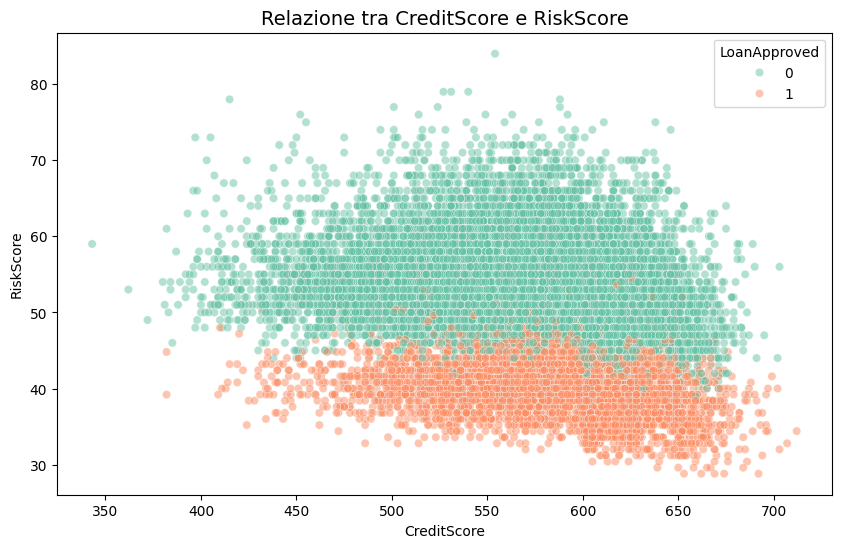

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='CreditScore', y='RiskScore', hue='LoanApproved', palette='Set2', alpha=0.5)

plt.title('Relazione tra CreditScore e RiskScore', fontsize=14)
plt.xlabel('CreditScore')
plt.ylabel('RiskScore')

plt.show()

Esiste una lieve correlazione negativa e diffusa tra le due variabili. In generale, all'aumentare del `CreditScore` il `RiskScore` tende ad abbassarsi leggermente, creando una nuvola di punti inclinata verso il basso.

L'elemento più lampante è la divisione orizzontale netta creata dai colori. I prestiti approvati (`LoanApproved` = 1, in arancione) si concentrano esclusivamente nella parte bassa del grafico, grosso modo sotto la soglia di `RiskScore` 48-50. Al contrario, i prestiti rifiutati (`LoanApproved` = 0, in azzurro) si trovano tutti al di sopra di questa soglia. Questo dimostra che il target che stiamo cercando di prevedere (`RiskScore`) è il criterio primario (se non unico) utilizzato dalla banca per decidere le approvazioni.

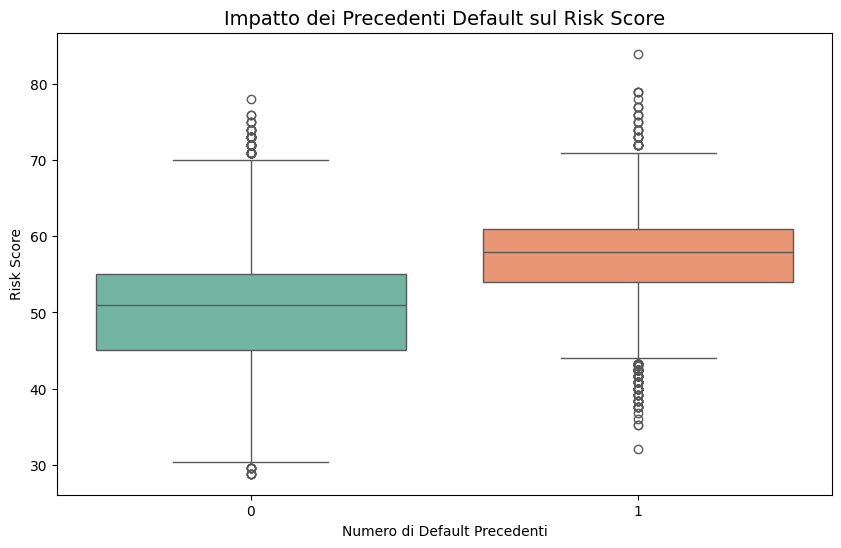

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='PreviousLoanDefaults', y='RiskScore', 
            hue='PreviousLoanDefaults', palette='Set2', legend=False)

plt.title('Impatto dei Precedenti Default sul Risk Score', fontsize=14)
plt.xlabel('Numero di Default Precedenti')
plt.ylabel('Risk Score')

plt.show()

Esiste un salto netto nel punteggio di rischio. Chi non ha mai avuto default ha una mediana di rischio intorno a **51**, mentre la presenza di un solo default fa balzare la mediana a circa **58**.

Anche il limite inferiore del rischio si alza notevolmente: quasi nessuno tra i clienti con un default precedente ottiene un `RiskScore` inferiore a 45, confermando che il sistema di scoring penalizza severamente i comportamenti passati negativi.

La separazione visiva tra i due "box" è molto marcata. Questo indica che la variabile `PreviousLoanDefaults` sarà uno dei predittori più pesanti sia per la Regressione Lineare che per XGBoost.

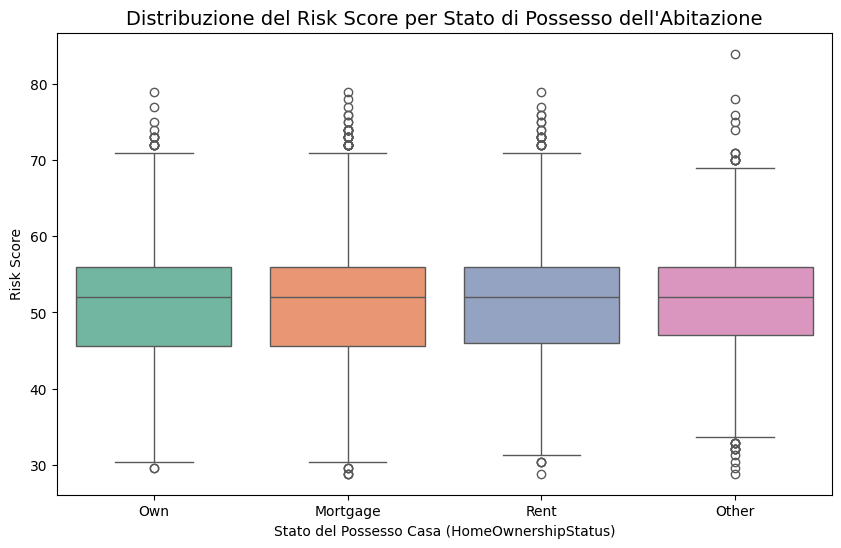

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='HomeOwnershipStatus', y='RiskScore', 
            hue='HomeOwnershipStatus', palette='Set2', legend=False)

plt.title('Distribuzione del Risk Score per Stato di Possesso dell\'Abitazione', fontsize=14)
plt.xlabel('Stato del Possesso Casa (HomeOwnershipStatus)')
plt.ylabel('Risk Score')

plt.show()

Le quattro categorie (*Own*, *Mortgage*, *Rent*, *Other*) presentano mediane e range interquartili quasi identici. Il punteggio medio di rischio non sembra variare significativamente a seconda che il cliente sia proprietario della casa, abbia un mutuo o sia in affitto.

La distribuzione dei dati e la presenza di outlier sono costanti in tutti i gruppi. Questo indica che, all'interno di questo specifico dataset, il possesso di un'abitazione non è un fattore discriminante primario per il calcolo del `RiskScore`.

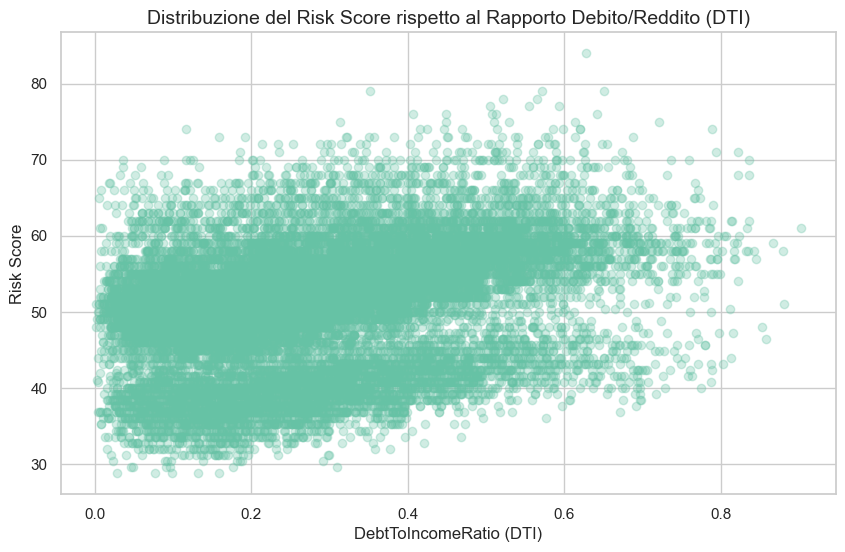

In [49]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='DebtToIncomeRatio', y='RiskScore', 
            fit_reg=False,
            scatter_kws={'alpha':0.3, 'color':'#66C2A5FF'}) 
plt.title('Distribuzione del Risk Score rispetto al Rapporto Debito/Reddito (DTI)', fontsize=14)
plt.xlabel('DebtToIncomeRatio (DTI)')
plt.ylabel('Risk Score')

plt.show()

Dal grafico è chiaramente visibile un trend ascendente. Spostandoci verso destra (DTI più elevato), l'intera massa di punti si solleva. Questo conferma che il peso dei debiti rispetto al reddito è un "driver" primario: più il cliente è indebitato, più il punteggio di rischio sale.

È interessante notare come la nuvola di punti non sia uniforme, ma sembri divisa in due "fasce" orizzontali di densità, specialmente nella parte sinistra del grafico. Questo riflette perfettamente quanto visto nell'istogramma iniziale (le due "gobbe"): esiste un gruppo di clienti valutato sistematicamente con un rischio più basso (fascia intorno a 35-40) e un gruppo più numeroso con rischio medio-alto (fascia 50-60).

Notiamo che per uno stesso valore di DTI (ad esempio 0.4), i punteggi di rischio spaziano da 35 a quasi 70. Questo indica che, sebbene il DTI sia importante, non è l'unico fattore decisivo. Esistono altre variabili nel dataset che "spostano" il cliente su o giù all'interno di questa nuvola.

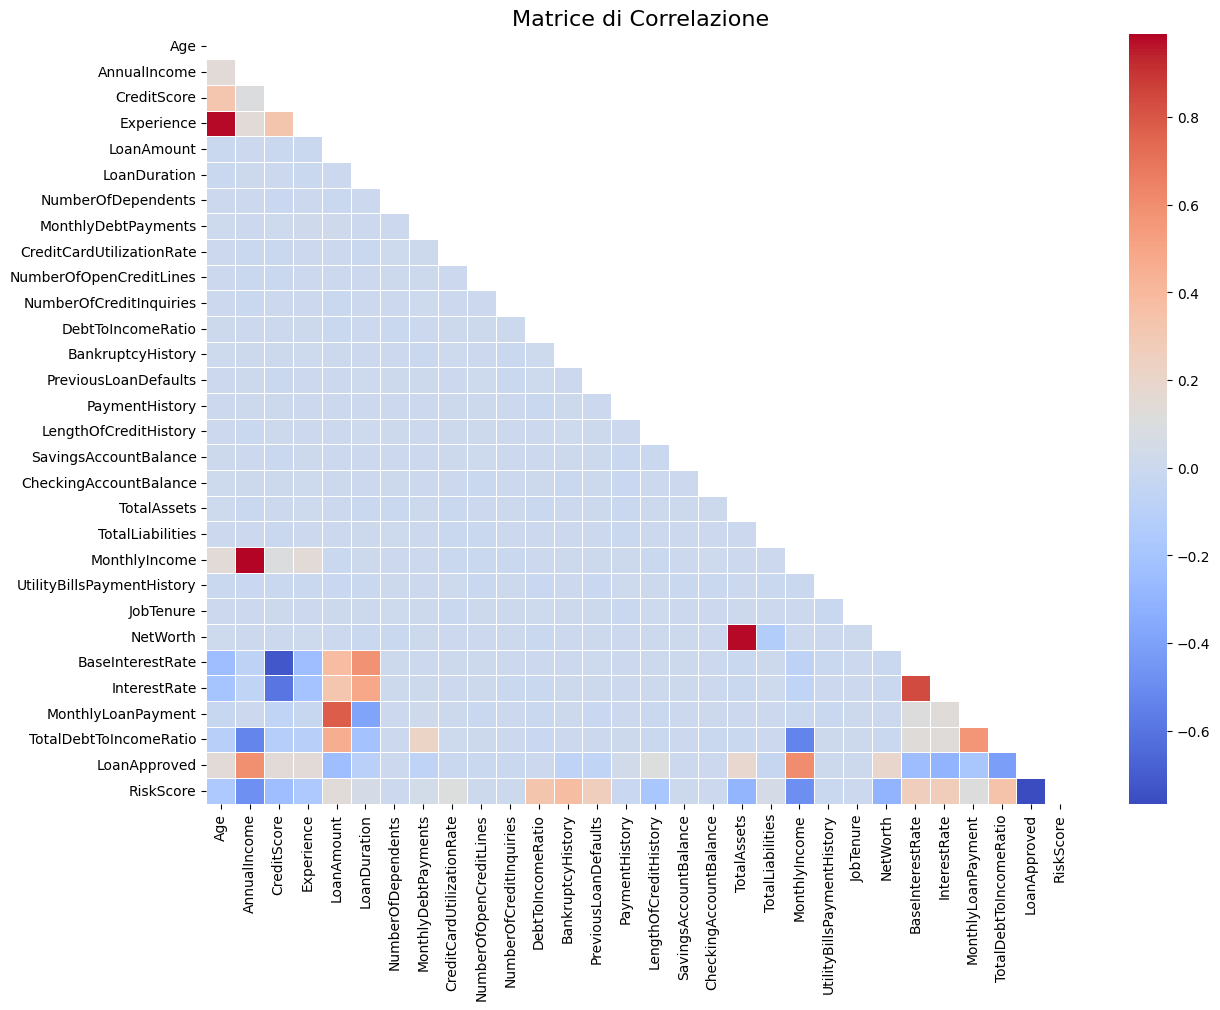

In [47]:
plt.figure(figsize=(14, 10))

# Variaibli numeriche
numeric_df = df.select_dtypes(include=[np.number])

# Correlazione di Pearson
corr_matrix = numeric_df.corr()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5)

plt.title('Matrice di Correlazione', fontsize=16)
plt.show()

Dalla mappa emergono diverse coppie di variabili quasi identiche tra loro. Inserire entrambe in un modello di **Regressione Lineare** creerebbe instabilità nei calcoli:
* **AnnualIncome e MonthlyIncome:** Presentano una correlazione perfetta (1.0). Forniscono la stessa informazione su scale diverse.
* **Age ed Experience:** Fortemente correlate, poiché l'esperienza lavorativa cresce naturalmente con l'età.
* **TotalAssets e NetWorth:** Relazione quasi diretta.
* **InterestRate e BaseInterestRate:** Estremamente correlate.

**Correlazione Negativa con CreditScore:** Conferma quanto visto nello scatterplot; all'aumentare del punteggio di credito, il rischio diminuisce sensibilmente.
**Correlazione Negativa con LoanApproved:** Conferma che il rischio è il fattore determinante per l'approvazione (un rischio alto porta a una mancata approvazione, valore 0).

## Preprocessing e Ottimizzazione dei Dati

## Modello 1: Linear Regression

## Modello 2: XGBRegressor

## Confronto dei Risultati

## Conclusione